In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def process_sentiment(sub_name):
    sent_map = {
        "positive": 1,
        "neutral": 0,
        "negative": -1}

    path = f"subs_sentiment/{sub_name}_sentiment.csv"
    df = pd.read_csv(path)
    df['sentiment'] = df['sentiment'].map(sent_map)
    df['log_pop'] = np.log(df['populairity']+1)
    df['log_pop'] = df['log_pop'] / df['log_pop'].max()
    df['time'] = pd.to_datetime(df['created_utc'], unit='s')
    df = df.set_index('time')
    df = df[['sentiment', 'log_pop']]
    df = df[df['sentiment']!=0]
    df = df[df['sentiment'].notna()]
    df['sentiment'] = df['sentiment'] * df['log_pop']
    df.sort_index(inplace=True)

    df = df.resample('h')['sentiment'].agg(['mean', 'std']).ffill().fillna(0)
    df.rename(columns={'mean': 'mean_sentiment', 'std': 'std_sentiment'}, inplace=True)

    # plt.plot(df.index, df['mean'])
    return df

In [6]:
market_df = pd.read_csv('nfl_historic_candlestick_hour.csv')
market_df['team'] = market_df['market'].apply(lambda x: x.split('-')[2])
market_df['event'] = market_df['market'].apply(lambda x: x.split('-')[1])
market_df = market_df[['end_period_ts','price.close_dollars','price.high_dollars','price.low_dollars','team','event']].ffill()
market_df['end_period_ts'] = pd.to_datetime(market_df['end_period_ts'], unit='s')
market_df = market_df.set_index('end_period_ts')
market_df = market_df[market_df.index >=pd.to_datetime('2025-08-28')]
# market_df = market_df.reset_index()
market_df

df_list = []
for event in market_df['event'].unique():
    event_df = market_df[market_df['event']==event]
    for team in event_df['team'].unique():
        event_df_team = event_df[event_df['team']==team]
        event_df_team = event_df_team.resample('h').ffill().fillna(0)
        df_list.append(event_df_team)
market_df = pd.concat(df_list)
market_df = market_df.reset_index()
market_df

,end_period_ts,price.close_dollars,price.high_dollars,price.low_dollars,team,event
0,2025-10-27 05:00:00,0.38,0.40,0.38,WAS,25NOV02SEAWAS
1,2025-10-27 06:00:00,0.39,0.39,0.39,WAS,25NOV02SEAWAS
2,2025-10-27 07:00:00,0.39,0.39,0.39,WAS,25NOV02SEAWAS
3,2025-10-27 08:00:00,0.39,0.39,0.39,WAS,25NOV02SEAWAS
4,2025-10-27 09:00:00,0.39,0.39,0.39,WAS,25NOV02SEAWAS
...,...,...,...,...,...,...
45309,2025-09-05 00:00:00,0.79,0.80,0.78,PHI,25SEP04DALPHI
45310,2025-09-05 01:00:00,0.65,0.82,0.46,PHI,25SEP04DALPHI
45311,2025-09-05 02:00:00,0.75,0.85,0.63,PHI,25SEP04DALPHI
45312,2025-09-05 03:00:00,0.80,0.84,0.37,PHI,25SEP04DALPHI


In [7]:
subs_df = pd.read_csv('reddit_subs.csv')
subs_df.dropna(inplace=True)
subs_list = []
for _,row in subs_df.iterrows():
    sub_sent_df = process_sentiment(row['Subreddit'])
    sub_sent_df['team'] = row['Team']
    sub_sent_df = sub_sent_df.round(2)
    subs_list.append(sub_sent_df)

sub_sent_df = pd.concat(subs_list)

In [9]:
sub_sent_df[sub_sent_df['team']=='PIT']
# plt.hist(sub_sent_df.index, bins=50)
# plt.show()
set(sub_sent_df.index.unique()) - set(market_df['end_period_ts'].unique())


{Timestamp('2025-08-28 14:00:00'),
 Timestamp('2025-08-28 15:00:00'),
 Timestamp('2025-08-28 16:00:00'),
 Timestamp('2025-08-28 17:00:00'),
 Timestamp('2025-08-28 18:00:00'),
 Timestamp('2025-08-28 19:00:00'),
 Timestamp('2025-08-28 20:00:00'),
 Timestamp('2025-08-28 21:00:00'),
 Timestamp('2025-08-28 22:00:00'),
 Timestamp('2025-08-28 23:00:00'),
 Timestamp('2025-08-29 00:00:00'),
 Timestamp('2025-08-29 01:00:00'),
 Timestamp('2025-08-29 02:00:00'),
 Timestamp('2025-08-29 03:00:00'),
 Timestamp('2025-08-29 04:00:00'),
 Timestamp('2025-11-04 05:00:00'),
 Timestamp('2025-11-04 06:00:00'),
 Timestamp('2025-11-04 07:00:00'),
 Timestamp('2025-11-04 08:00:00'),
 Timestamp('2025-11-04 09:00:00'),
 Timestamp('2025-11-04 10:00:00'),
 Timestamp('2025-11-04 11:00:00'),
 Timestamp('2025-11-04 12:00:00'),
 Timestamp('2025-11-04 13:00:00'),
 Timestamp('2025-11-04 14:00:00'),
 Timestamp('2025-11-04 15:00:00'),
 Timestamp('2025-11-04 16:00:00'),
 Timestamp('2025-11-04 17:00:00'),
 Timestamp('2025-11-

In [ ]:
df = market_df.merge(sub_sent_df, left_on=['end_period_ts','team'], right_on=['time','team'], how='left')
df.dropna(inplace=True)
df.set_index('end_period_ts', inplace=True)
df.to_csv('kalshi_reddit_sentiment_combined.csv', index=True)
df

,price.close_dollars,price.high_dollars,price.low_dollars,team,event,mean_sentiment,std_sentiment
end_period_ts,,,,,,,
2025-10-27 05:00:00,0.38,0.40,0.38,WAS,25NOV02SEAWAS,0.65,0.00
2025-10-27 06:00:00,0.39,0.39,0.39,WAS,25NOV02SEAWAS,0.65,0.00
2025-10-27 07:00:00,0.39,0.39,0.39,WAS,25NOV02SEAWAS,0.65,0.00
2025-10-27 08:00:00,0.39,0.39,0.39,WAS,25NOV02SEAWAS,0.65,0.00
2025-10-27 09:00:00,0.39,0.39,0.39,WAS,25NOV02SEAWAS,0.65,0.00
...,...,...,...,...,...,...,...
2025-09-07 16:00:00,0.40,0.41,0.39,NYJ,25SEP07PITNYJ,0.55,0.72
2025-09-07 17:00:00,0.40,0.41,0.38,NYJ,25SEP07PITNYJ,0.55,0.72
2025-09-07 18:00:00,0.67,0.68,0.27,NYJ,25SEP07PITNYJ,0.55,0.72


### Quick Modeling

In [ ]:
df.groupby('team').size()

team
ARI     503
BAL     654
BUF     336
CAR     153
CHI       1
CIN     534
CLE     997
DAL     834
DEN     266
GB      246
HOU     504
IND     137
JAC     660
KC      943
LA      468
LAC     653
LV      168
MIA     460
MIN      68
NE       94
NO      841
NYG     335
NYJ    1344
PHI      70
PIT     347
SEA     168
SF      875
TB      882
TEN     989
WAS     319
dtype: int64

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-734.360, Time=0.44 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-508.279, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-640.397, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-696.559, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-510.208, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-735.705, Time=0.35 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-737.175, Time=0.25 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-735.058, Time=0.33 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-735.971, Time=0.26 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-733.441, Time=0.38 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=-737.442, Time=0.25 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-710.467, Time=0.11 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=-735.839, Time=0.26 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=-735.829, Time=0.35 sec
 ARIMA(1,1,1)(0,0,0)[0]          

c:\Users\cowil\OneDrive\Python\Capstone\Kalshi_stat_arb\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\cowil\OneDrive\Python\Capstone\Kalshi_stat_arb\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


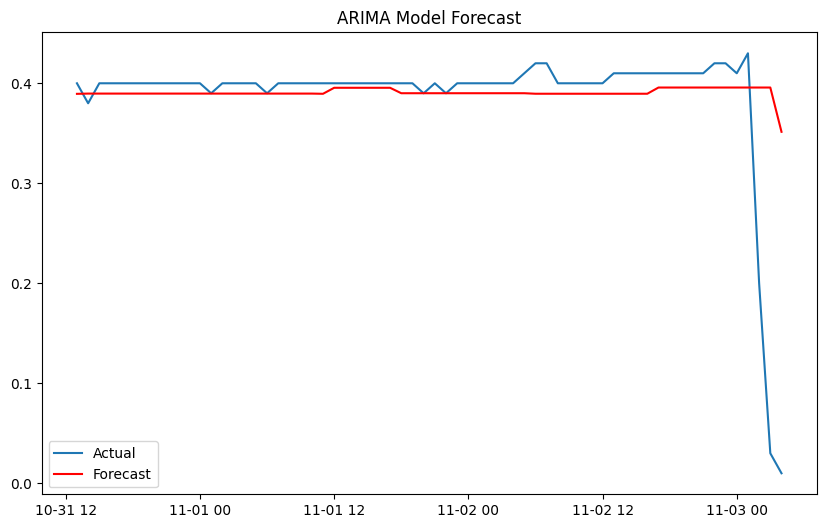

In [36]:
from pmdarima import auto_arima
from sklearn.model_selection import train_test_split

team = 'WAS'
train_df = df[df['team']==team].copy()
train_df.sort_index(inplace=True)
train_df
train_df['price.close_prev'] = train_df['price.close_dollars'].shift(1)
train_df['price.high_prev'] = train_df['price.high_dollars'].shift(1)
train_df['price.low_prev'] = train_df['price.low_dollars'].shift(1)
train_df.dropna(inplace=True)  

# Define the target variable and exogenous variable
y = train_df['price.close_dollars']
X = train_df[['mean_sentiment', 'std_sentiment']] #,'price.close_prev','price.high_prev','price.low_prev'

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Fit the ARIMA model with exogenous variable
model = auto_arima(y_train, X=X_train, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)

# Summary of the model
print(model.summary())

# Make predictions
forecast = model.predict(n_periods=len(X_test), X=X_test)

# Compare predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, forecast, label='Forecast', color='red')
plt.legend()
plt.title('ARIMA Model Forecast')
plt.show()